In [ ]:
import os
os.chdir('..')
if os.path.exists('Groenbeeld'):
  !rm -rf Groenbeeld

In [ ]:
import sys
!{sys.executable} -m pip install owslib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.5/240.5 kB 7.4 MB/s eta 0:00:00


In [ ]:
import os

!git clone https://github.com/bart314/Groenbeeld.git
os.chdir('Groenbeeld')
!git checkout clustering
!ls

Cloning into 'Groenbeeld'...
remote: Enumerating objects: 235, done.
remote: Counting objects: 100% (96/96), done.
remote: Compressing objects: 100% (80/80), done.
remote: Total 235 (delta 49), reused 38 (delta 15), pack-reused 139 (from 1)
Receiving objects: 100% (235/235), 13.38 MiB | 9.68 MiB/s, done.
Resolving deltas: 100% (113/113), done.
Branch 'clustering' set up to track remote branch 'clustering' from 'origin'.
Switched to a new branch 'clustering'
Data	    NDVI-SWF.yaml  README.md  targets.txt
LICENSE.md  outdir	   Scripts    Tutorial_grondwaterstand


In [ ]:
import os

# Define the expected output path for the CIR data from the previous script.
# This assumes 'outdir/municipality_survey_V2/BU19000102_Stationsbuurt_CIR.tif'
# is a reliable indicator that the script has already run successfully.
output_dir = 'outdir/municipality_survey_V2'
target_id_prefix = 'BU19000102_Stationsbuurt' # Based on previous script output and subsequent cell usage
expected_output_file = os.path.join(output_dir, f"{target_id_prefix}_CIR.tif")

# Ensure the output directory structure is created for the check
os.makedirs(output_dir, exist_ok=True)

if os.path.exists(expected_output_file):
    print(f"Detected existing output file: {expected_output_file}. Skipping `Municipality_Surveyor_V2.py` execution.")
else:
    print(f"Output file {expected_output_file} not found. Running `Municipality_Surveyor_V2.py` to generate data...")
    !python3 "Scripts/Municipality_Surveyor_V2.py"

Output file outdir/municipality_survey_V2/BU19000102_Stationsbuurt_CIR.tif not found. Running `Municipality_Surveyor_V2.py` to generate data...
Loaded 1 targets from targets.txt
Initializing CIR WMTS service...
Initializing RGB WMTS service...
Initiatlizing BRT WMTS service...
Initializing BRT-A Background service...
Initializing BGT WMTS service...
WMTS initialized. Resolution: 0.21m/px
Initializing KEA WMS service...
Connecting to Sogelink Server for ['gevoelstemperatuur_2022', 'RMK_BKB_AHN4', 'RMK_SchaduwGrijs_AHN4', 'RMK_SchaduwGroen_AHN4', 'BGV_ONO_2024', 'BGV_landbedekking_2024', 'RMK_30percBKB_AHN4']...
 SUCCESS: Layer 'gevoelstemperatuur_2022' found.
 SUCCESS: Layer 'RMK_BKB_AHN4' found.
 SUCCESS: Layer 'RMK_SchaduwGrijs_AHN4' found.
 SUCCESS: Layer 'RMK_SchaduwGroen_AHN4' found.
 SUCCESS: Layer 'BGV_ONO_2024' found.
 SUCCESS: Layer 'BGV_landbedekking_2024' found.
 SUCCESS: Layer 'RMK_30percBKB_AHN4' found.
 ERROR: Could not retrieve capabilities.
Fetching all buurten for Súdwe

In [ ]:
!python3 "/Groenbeeld/Scripts/Exploratory_Clustering.py"

Loaded 1 targets from targets.txt

Processing Target: BU19000102
Error: Could not find all required TIF files for BU19000102 in outdir/municipality_survey


In [ ]:
import sys
!{sys.executable} -m pip install rasterio matplotlib

Current working directory already Groenbeeld: /Groenbeeld
Current working directory: /Groenbeeld
Checking for directory: outdir/municipality_survey_V2

--- Contents of 'outdir' (recursive) ---
outdir:
exploratory_analysis  Jenks_stat_2.txt
Jenks_counts.npy      municipality_survey_V2

outdir/exploratory_analysis:
Stationsbuurt_clusters.qml	 Stationsbuurt_elbow_plot.png
Stationsbuurt_cluster_stats.csv

outdir/municipality_survey_V2:
BU19000102_Stationsbuurt_BGT.tif
BU19000102_Stationsbuurt_BRTA.tif
BU19000102_Stationsbuurt_BRT.tif
BU19000102_Stationsbuurt_CHM.tif
BU19000102_Stationsbuurt_CIR.tif
BU19000102_Stationsbuurt_DSM.tif
BU19000102_Stationsbuurt_DTM.tif
BU19000102_Stationsbuurt_KEA_BGV_landbedekking_2024.tif
BU19000102_Stationsbuurt_KEA_BGV_ONO_2024.tif
BU19000102_Stationsbuurt_KEA_gevoelstemperatuur_2022.tif
BU19000102_Stationsbuurt_KEA_RMK_30percBKB_AHN4.tif
BU19000102_Stationsbuurt_KEA_RMK_BKB_AHN4.tif
BU19000102_Stationsbuurt_KEA_RMK_SchaduwGrijs_AHN4.tif
BU19000102_Stationsb

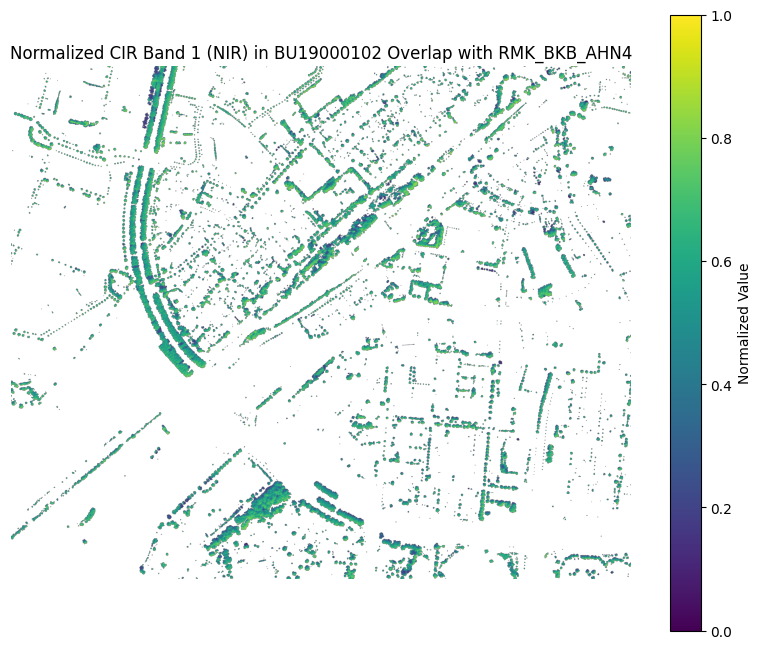

Normalized CIR map saved to: outdir/BU19000102_CIR_RMK_BKB_AHN4_normalized.tif


In [ ]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Ensure current working directory is 'Groenbeeld' for relative paths to work correctly
if os.path.basename(os.getcwd()) != 'Groenbeeld':
    print(f"Changing directory from {os.getcwd()} to /content/Groenbeeld")
    os.chdir('/content/Groenbeeld')
    print(f"Current working directory is now: {os.getcwd()}")
else:
    print(f"Current working directory already Groenbeeld: {os.getcwd()}")


# Assuming the current working directory is 'Groenbeeld'
base_output_dir = 'outdir/municipality_survey_V2'
target_id = 'BU19000102'
# Fix: The output files are directly in base_output_dir, not in a subfolder named target_id
neighborhood_dir = base_output_dir # Corrected line

print(f"Current working directory: {os.getcwd()}")
print(f"Checking for directory: {neighborhood_dir}")

# Diagnostic: List contents of 'outdir' to understand actual structure
print("\n--- Contents of 'outdir' (recursive) ---")
!ls -R outdir
print("--------------------------------------\n")

if os.path.exists(neighborhood_dir):
    for f in os.listdir(neighborhood_dir):
        # Diagnostic: Only print files if they match the expected pattern or are relevant
        if target_id in f or f.endswith(('.npy', '.tif')):
            print(f)
else:
    print(f"Directory not found: {neighborhood_dir}")
    raise FileNotFoundError(f"Required directory {neighborhood_dir} does not exist.")

# Determine the full neighborhood name for correct file paths
# From the `ls` output and previous script's logs, it appears the full name is 'BU19000102_Stationsbuurt'
neighborhood_full_name = f"{target_id}_Stationsbuurt"

# Define file paths for the CIR data (now from a TIFF) and the KEA layer
cir_data_path = os.path.join(neighborhood_dir, f"{neighborhood_full_name}_CIR.tif")
kea_layer_path = os.path.join(neighborhood_dir, f"{neighborhood_full_name}_KEA_RMK_BKB_AHN4.tif")
geo_ref_path = os.path.join(neighborhood_dir, f"{neighborhood_full_name}_DSM.tif") # Use DSM for georeferencing

# Check if all necessary files exist
if not os.path.exists(cir_data_path):
    raise FileNotFoundError(f"Error: CIR data file not found at {cir_data_path}")
if not os.path.exists(kea_layer_path):
    raise FileNotFoundError(f"Error: KEA layer file not found at {kea_layer_path}")
if not os.path.exists(geo_ref_path):
    raise FileNotFoundError(f"Error: Georeference file not found at {geo_ref_path}")

# Load CIR array from .tif file using rasterio
cir_map = None
try:
    with rasterio.open(cir_data_path) as src_cir:
        # Assuming CIR is a multi-band image (e.g., NIR-Red-Green)
        # Read all bands. Rasterio reads bands as (count, height, width)
        cir_map = src_cir.read()
        print(f"Loaded CIR map from TIFF with shape: {cir_map.shape}")
except Exception as e:
    raise RuntimeError(f"Failed to load CIR data from {cir_data_path}: {e}")

# Load KEA layer (RMK_BKB_AHN4)
kea_profile = None
kea_data = None
try:
    with rasterio.open(kea_layer_path) as src_kea:
        kea_data = src_kea.read(1) # Read the first band
        kea_profile = src_kea.profile
        print(f"Loaded KEA layer with shape: {kea_data.shape}")
        print(f"KEA layer profile: {kea_profile}")
except Exception as e:
    raise RuntimeError(f"Failed to load KEA layer from {kea_layer_path}: {e}")

# Get georeferencing information from a reference GeoTIFF (e.g., DSM.tif)
geo_ref_profile = None
try:
    with rasterio.open(geo_ref_path) as src_ref:
        geo_ref_profile = src_ref.profile
        print(f"Georeference profile from {geo_ref_path}: {geo_ref_profile}")
except Exception as e:
    raise RuntimeError(f"Failed to load georeference data from {geo_ref_path}: {e}")

# Ensure all data is loaded and dimensions match
expected_height = geo_ref_profile['height']
expected_width = geo_ref_profile['width']

if cir_map.shape[1] != expected_height or cir_map.shape[2] != expected_width:
    raise ValueError(f"CIR map dimensions ({cir_map.shape[1]}, {cir_map.shape[2]}) "
                     f"do not match reference GeoTIFF dimensions ({expected_height}, {expected_width}).")

if kea_data.shape[0] != expected_height or kea_data.shape[1] != expected_width:
    raise ValueError(f"KEA layer dimensions ({kea_data.shape}) do not match reference GeoTIFF dimensions ({expected_height}, {expected_width}).")

print("CIR map and KEA layer dimensions are consistent with reference GeoTIFF.")

# Create an overlap mask from kea_data
# Assuming non-zero values in `kea_data` indicate the region of interest for overlap
overlap_mask = kea_data > 0

# Apply the mask to each band of the CIR map
masked_cir = np.empty_like(cir_map, dtype=float)
for i in range(cir_map.shape[0]):
    band_data = cir_map[i, :, :].astype(float) # Ensure float for calculations
    band_data[~overlap_mask] = np.nan # Set non-overlap regions to NaN
    masked_cir[i, :, :] = band_data

print(f"Masked CIR map shape: {masked_cir.shape}")

# Normalize CIR values within the overlap region (min-max normalization to 0-1)
normalized_masked_cir = np.empty_like(masked_cir)

for i in range(masked_cir.shape[0]):
    band_values = masked_cir[i, :, :]
    valid_values = band_values[~np.isnan(band_values)]

    if valid_values.size > 0:
        min_val = np.min(valid_values)
        max_val = np.max(valid_values)

        if max_val - min_val > 0:
            normalized_band = (band_values - min_val) / (max_val - min_val)
            # Restore NaN for non-overlap regions
            normalized_band[np.isnan(band_values)] = np.nan
        else: # All valid values are the same in the overlap region
            normalized_band = np.full_like(band_values, np.nan)
            normalized_band[~np.isnan(band_values)] = 0.5 # Set to mid-range if all values are constant
    else: # No valid values in this band for the overlap region
        normalized_band = np.full_like(band_values, np.nan)

    normalized_masked_cir[i, :, :] = normalized_band

print(f"Normalized masked CIR map shape: {normalized_masked_cir.shape}")
print("Normalization complete. Values in overlap region are scaled between 0 and 1 (or NaN elsewhere).")

# Visualize a band of the normalized CIR map (e.g., the first band)
plt.figure(figsize=(10, 8))
plt.imshow(normalized_masked_cir[0, :, :], cmap='viridis', vmin=0, vmax=1)
plt.title(f"Normalized CIR Band 1 (NIR) in {target_id} Overlap with RMK_BKB_AHN4")
plt.colorbar(label="Normalized Value")
plt.axis('off')
plt.show()

# Save the normalized CIR map as a GeoTIFF
output_profile = geo_ref_profile.copy()
output_profile.update({
    'dtype': rasterio.float32,
    'count': cir_map.shape[0], # Number of bands in CIR
    'nodata': np.nan # Use NaN as nodata value
})

# Define the user-specified output directory
user_output_dir = 'outdir'

# Create the output directory if it doesn't exist
os.makedirs(user_output_dir, exist_ok=True)

output_path = os.path.join(user_output_dir, f"{target_id}_CIR_RMK_BKB_AHN4_normalized.tif")
try:
    with rasterio.open(output_path, 'w', **output_profile) as dst:
        for i in range(normalized_masked_cir.shape[0]):
            dst.write(normalized_masked_cir[i].astype(rasterio.float32), i + 1)
    print(f"Normalized CIR map saved to: {output_path}")
except Exception as e:
    print(f"Error saving normalized CIR map: {e}")

/tmp/ipykernel_4234/3553876986.py:49: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis') # 'viridis' is a good perceptually uniform colormap


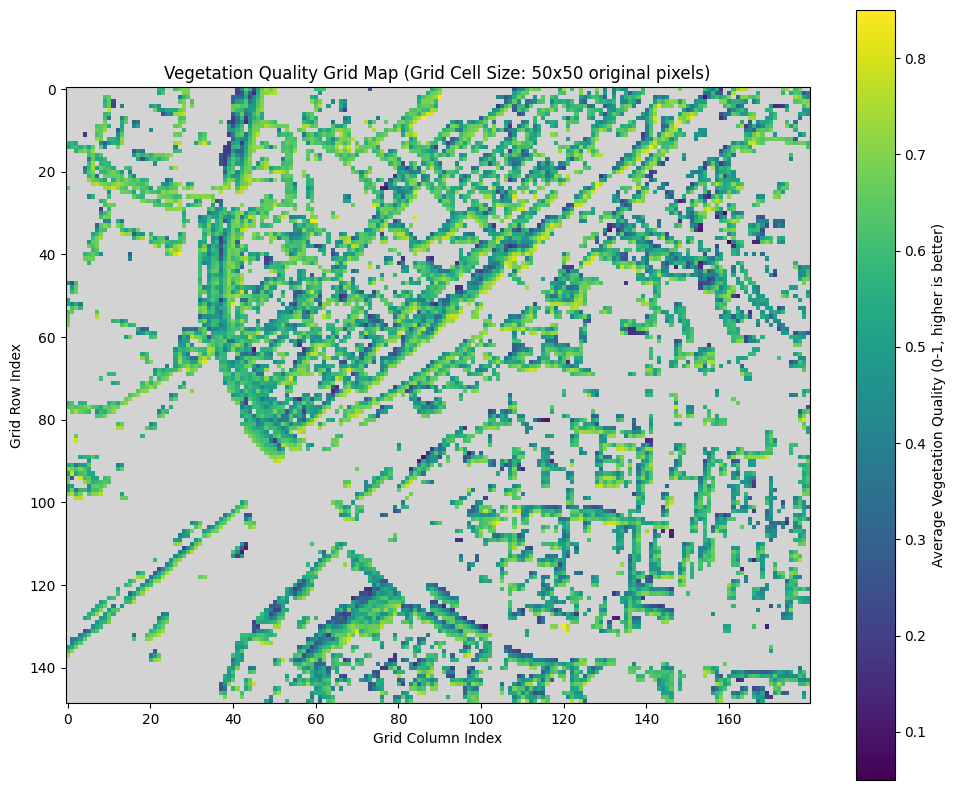

Generated a vegetation quality grid map with dimensions: 149x180 cells.
Each cell represents an area of 50x50 original pixels. Light gray indicates no vegetation present.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming normalized_masked_cir is available from the previous cell
# normalized_masked_cir shape: (3, height, width)

# Select the NIR band (band 0) for quality assessment, as it's strongly correlated with vegetation health
nir_band = normalized_masked_cir[0, :, :]

# Define grid cell size in pixels from the original image dimensions
grid_cell_size = 50 # Each grid cell will cover 50x50 pixels of the original image

# Get dimensions of the NIR band
height, width = nir_band.shape

# Calculate number of grid cells in the new grid map
grid_height = int(np.ceil(height / grid_cell_size))
grid_width = int(np.ceil(width / grid_cell_size))

# Initialize an array to store average vegetation quality per grid cell
# Using NaN to represent 'unknown' or 'no vegetation' as per the prompt
vegetation_quality_grid = np.full((grid_height, grid_width), np.nan)

# Iterate through each grid cell
for i in range(grid_height):
    for j in range(grid_width):
        # Define the pixel boundaries for the current grid cell in the original image
        row_start = i * grid_cell_size
        row_end = min((i + 1) * grid_cell_size, height)
        col_start = j * grid_cell_size
        col_end = min((j + 1) * grid_cell_size, width)

        # Extract the values within the current grid cell from the NIR band
        cell_values = nir_band[row_start:row_end, col_start:col_end]

        # Filter out NaN values (indicating no vegetation present in those specific pixels)
        valid_vegetation_values = cell_values[~np.isnan(cell_values)]

        # Calculate average quality if vegetation is present in the grid cell
        # This fulfills 'only the quality of which is present' and ignores 'amount'
        if valid_vegetation_values.size > 0:
            vegetation_quality_grid[i, j] = np.mean(valid_vegetation_values)
        # If no valid vegetation values, the cell remains NaN, representing 'unknown' or 'no vegetation'

# Plot the grid map
plt.figure(figsize=(12, 10))

# Create a colormap and set a specific color for NaN values to represent 'unknown' / 'no vegetation'
cmap = plt.cm.get_cmap('viridis') # 'viridis' is a good perceptually uniform colormap
cmap.set_bad('lightgray') # Set NaN values to light gray for clarity

plt.imshow(vegetation_quality_grid, cmap=cmap, origin='upper',
           interpolation='nearest') # 'nearest' is suitable for grid data visualization

plt.colorbar(label="Average Vegetation Quality (0-1, higher is better)")
plt.title(f"Vegetation Quality Grid Map (Grid Cell Size: {grid_cell_size}x{grid_cell_size} original pixels)")
plt.xlabel("Grid Column Index")
plt.ylabel("Grid Row Index")
plt.show()

print(f"Generated a vegetation quality grid map with dimensions: {grid_height}x{grid_width} cells.")
print(f"Each cell represents an area of {grid_cell_size}x{grid_cell_size} original pixels. Light gray indicates no vegetation present.")